# Northgate Student Visualization Assignment

**INFO 4670 · Week 3**  
**Student:** Jackson Moody

This notebook answers the five guided questions and one original question using the Northgate files. Each figure is fully labeled and followed by a STAR story: **Scope · Track · Articulate · Respond**.

### Colab directions
Upload `student_records.csv`, `weekly_activity.csv`, and `course_enrollments.csv` into the Colab file panel, then choose **Runtime → Run all**.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style from the guided notebook
NAVY = "#22303A"
RUST = "#C0562F"
TEAL = "#2A7F7F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 110

In [2]:
# The default works when the three CSV files are uploaded beside this notebook.
DATA_DIR = "."

students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
courses = pd.read_csv(os.path.join(DATA_DIR, "course_enrollments.csv"))

print(f"Student records: {students.shape[0]:,} rows × {students.shape[1]} columns")
print(f"Weekly activity: {weekly.shape[0]:,} rows × {weekly.shape[1]} columns")
print(f"Course enrollments: {courses.shape[0]:,} rows × {courses.shape[1]} columns")
print(f"Unique students in student_records: {students['student_id'].nunique():,}")

Student records: 2,027 rows × 12 columns
Weekly activity: 32,000 rows × 4 columns
Course enrollments: 8,088 rows × 4 columns
Unique students in student_records: 2,000


## Part A1 — How many hours per week do Northgate students work?

A histogram shows the distribution's shape and typical values, while the compact box plot makes the range and unusual values easier to see.

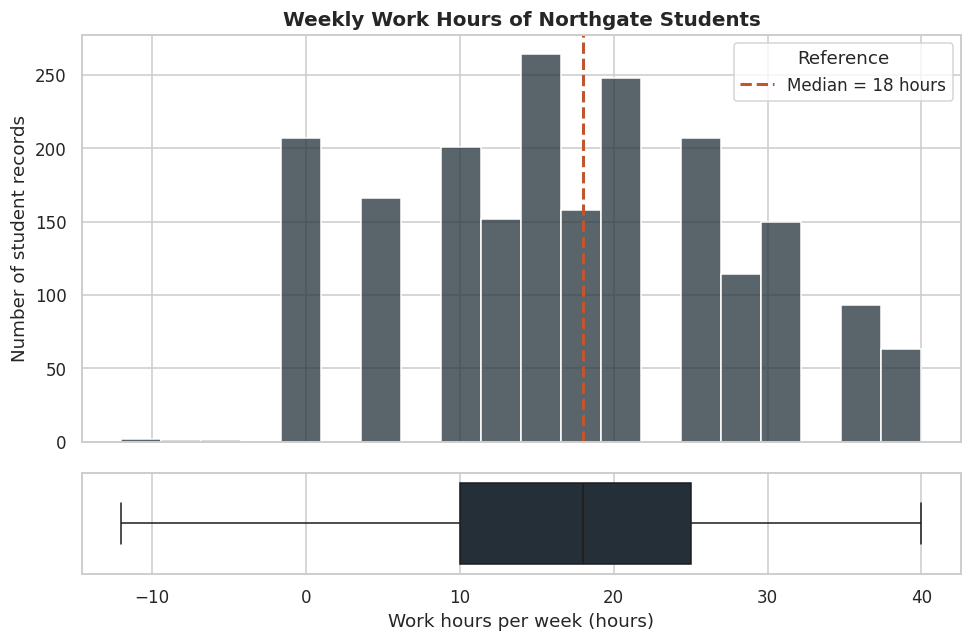

In [3]:
fig, (ax_hist, ax_box) = plt.subplots(
    2, 1, figsize=(9, 6), sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}
)
sns.histplot(data=students, x="work_hours_per_week", bins=20,
             color=NAVY, edgecolor="white", ax=ax_hist)
ax_hist.axvline(students["work_hours_per_week"].median(), color=RUST,
                linestyle="--", linewidth=2, label="Median = 18 hours")
ax_hist.set_title("Weekly Work Hours of Northgate Students")
ax_hist.set_xlabel("")
ax_hist.set_ylabel("Number of student records")
ax_hist.legend(title="Reference")

sns.boxplot(data=students, x="work_hours_per_week", color=NAVY, ax=ax_box)
ax_box.set_xlabel("Work hours per week (hours)")
ax_box.set_ylabel("")
plt.tight_layout()
plt.show()

**STAR story**

- **Scope:** I examined how many hours Northgate students report working each week to identify what is typical, how much schedules vary, and whether any records stand apart.
- **Track:** I used a histogram because work hours are quantitative and added a box plot to summarize the median, quartiles, and extremes. The histogram includes a labeled median reference line.
- **Articulate:** The typical student works **18 hours per week**. The middle 50% runs from **10 to 25 hours**, while the full recorded range is **−12 to 40 hours**. Values cluster at common schedules such as 0, 10, 15, 20, and 25 hours. The **−12-hour record is impossible**, even though it falls just inside the mechanical 1.5-IQR fence; it is a validity problem that should not be ignored.
- **Respond:** Northgate should confirm or correct the negative value and consider validation rules that reject work hours below zero. Students near the high end of 35–40 hours may also merit workload check-ins, but the chart alone does not show that employment caused academic difficulty.

## Part A2 — How does enrollment compare across majors?

A sorted horizontal bar chart makes category counts easy to compare and keeps long major names readable.

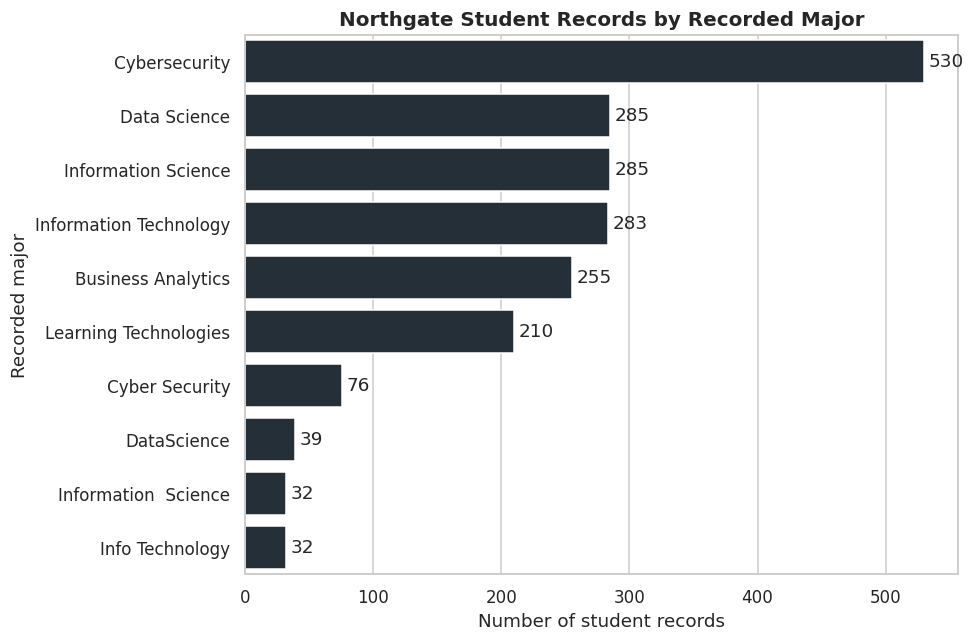

In [4]:
major_order = students["major"].value_counts().index
fig, ax = plt.subplots(figsize=(9, 6))
sns.countplot(data=students, y="major", order=major_order, color=NAVY, ax=ax)
ax.set_title("Northgate Student Records by Recorded Major")
ax.set_xlabel("Number of student records")
ax.set_ylabel("Recorded major")
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%d")
plt.tight_layout()
plt.show()

**STAR story**

- **Scope:** I compared enrollment across the majors recorded in the student file.
- **Track:** I used a sorted horizontal bar chart because major is categorical and the question asks for counts. Sorting puts the largest groups first and data labels provide exact units.
- **Articulate:** **Cybersecurity** is the largest recorded category with **530 records**, followed by **Data Science** and **Information Science** with **285 each** and **Information Technology** with **283**. However, the chart displays **10 labels when only six majors appear to be intended**. Variants such as “Cyber Security,” “DataScience,” “Information  Science,” and “Info Technology” split students across duplicate categories. There are also 2,027 records but only 2,000 unique student IDs, so these are record counts rather than a clean unduplicated headcount.
- **Respond:** Northgate should standardize major names with an approved lookup list and resolve duplicate student IDs before reporting official enrollment. Until then, the chart should be interpreted as a view of raw recorded categories, not final enrollment totals.

## Part A3 — Does final GPA differ across majors?

Side-by-side box plots compare the centers and spreads while retaining unusual GPA values as individual points.

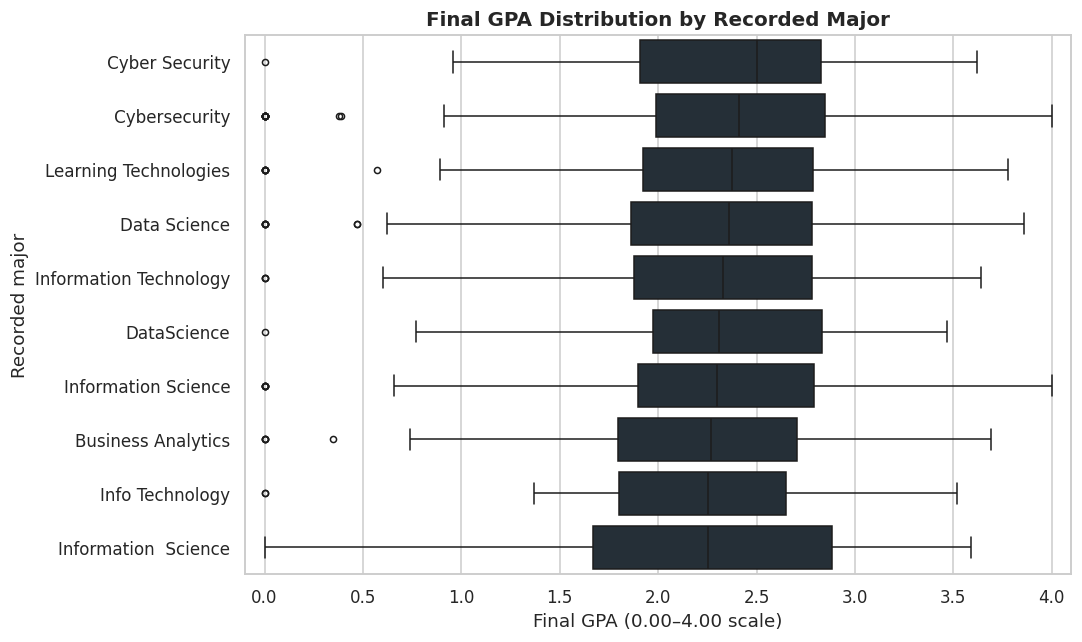

In [5]:
gpa_order = students.groupby("major")["final_gpa"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=students, x="final_gpa", y="major", order=gpa_order,
            color=NAVY, fliersize=4, ax=ax)
ax.set_title("Final GPA Distribution by Recorded Major")
ax.set_xlabel("Final GPA (0.00–4.00 scale)")
ax.set_ylabel("Recorded major")
ax.set_xlim(-0.1, 4.1)
plt.tight_layout()
plt.show()

**STAR story**

- **Scope:** I compared final GPA distributions across recorded majors to see whether any program has a noticeably different center, spread, or set of exceptions.
- **Track:** I used one horizontal box plot per recorded major because GPA is quantitative and major is categorical. The dots beyond the whiskers preserve exceptional records instead of hiding them inside averages.
- **Articulate:** The boxes overlap heavily, so the typical GPA is broadly similar across groups. Recorded medians range from about **2.26** for “Information  Science” and “Info Technology” to **2.50** for “Cyber Security.” The more important exception is the cluster of **43 exact 0.00 GPAs**, including students in nearly every recorded major. The category spelling variants also create small artificial groups, making their boxes less stable and comparisons less trustworthy.
- **Respond:** Northgate should review the 0.00 records to determine whether they represent true performance, withdrawals, or missing outcomes encoded as zero. It should also standardize majors before comparing programs. The present chart does not support claiming that a student's major causes a higher or lower GPA.

## Part A4 — Is commute distance related to final GPA?

A scatterplot shows individual students, and a fitted linear trend summarizes the direction of the association.

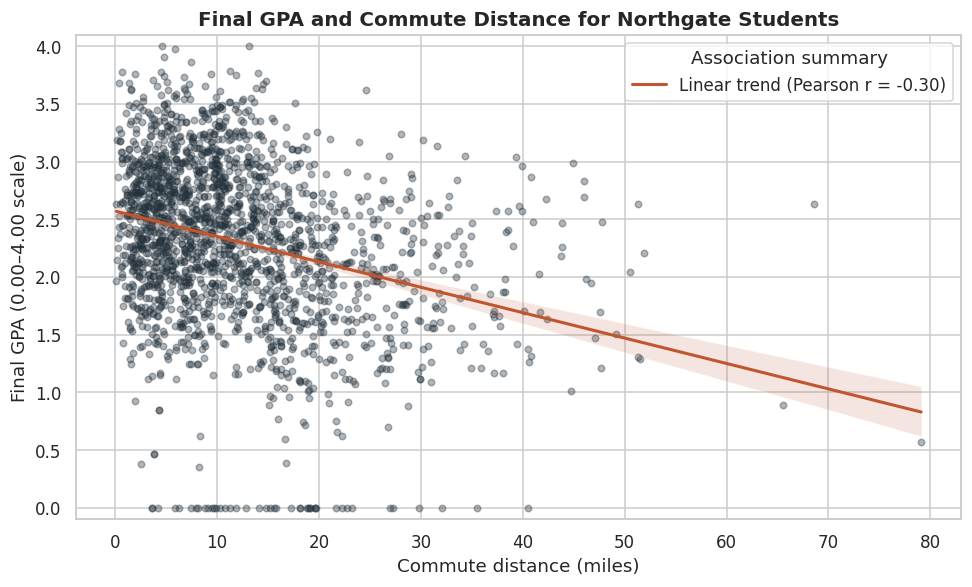

In [6]:
r = students["commute_miles"].corr(students["final_gpa"])
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.regplot(data=students, x="commute_miles", y="final_gpa",
            scatter_kws={"s": 18, "color": NAVY, "alpha": 0.35},
            line_kws={"color": RUST, "linewidth": 2,
                       "label": f"Linear trend (Pearson r = {r:.2f})"},
            ax=ax)
ax.set_title("Final GPA and Commute Distance for Northgate Students")
ax.set_xlabel("Commute distance (miles)")
ax.set_ylabel("Final GPA (0.00–4.00 scale)")
ax.set_ylim(-0.1, 4.1)
ax.legend(title="Association summary")
plt.tight_layout()
plt.show()

**STAR story**

- **Scope:** I examined whether students with longer commutes tend to have different final GPAs.
- **Track:** I used a scatterplot because both commute distance and GPA are quantitative. The fitted line and Pearson correlation summarize the overall direction without replacing the individual observations.
- **Articulate:** The trend slopes downward, and the Pearson correlation is approximately **−0.30**, indicating a modest negative association: longer commutes tend to accompany lower GPAs in this dataset. The points remain widely scattered, commute distances extend to **79.1 miles**, and 0.00-GPA records appear at multiple distances.
- **Respond:** Northgate could include commute burden in early-support screening and ask long-distance commuters about transportation, scheduling, or online-access needs. This is an association, not evidence that commuting causes lower GPA; employment, housing, course load, or other factors may influence both.

## Part A5 — How does engagement change across the semester?

A line chart is appropriate because week is ordered time and the goal is to follow change in average LMS activity.

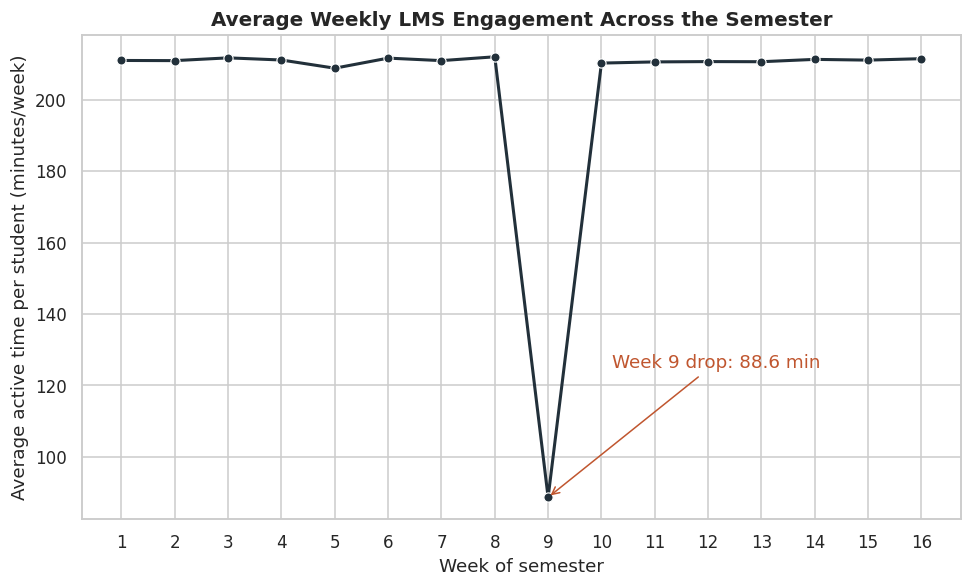

In [7]:
weekly_avg = weekly.groupby("week", as_index=False)["minutes_active"].mean()
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.lineplot(data=weekly_avg, x="week", y="minutes_active",
             color=NAVY, marker="o", linewidth=2, ax=ax)
week9 = weekly_avg.loc[weekly_avg["week"].eq(9), "minutes_active"].iloc[0]
ax.annotate(f"Week 9 drop: {week9:.1f} min",
            xy=(9, week9), xytext=(10.2, 125),
            arrowprops={"arrowstyle": "->", "color": RUST}, color=RUST)
ax.set_title("Average Weekly LMS Engagement Across the Semester")
ax.set_xlabel("Week of semester")
ax.set_ylabel("Average active time per student (minutes/week)")
ax.set_xticks(range(1, 17))
plt.tight_layout()
plt.show()

**STAR story**

- **Scope:** I tracked average LMS engagement across the 16-week semester to see whether participation declines gradually or changes at a specific point.
- **Track:** I used a line chart because week is ordered time. Each point is the average active minutes for **2,000 students**, and the connected points make changes from week to week visible.
- **Articulate:** Engagement is remarkably stable at roughly **209–212 minutes per student per week** in every week except Week 9. In Week 9, the average falls to **88.6 minutes**, about **58% below Week 8**, then returns to **210.3 minutes** in Week 10. This is a one-week interruption, not a semester-long decline.
- **Respond:** Northgate should first check the academic calendar and LMS collection process for Week 9, since a break, outage, or incomplete extract could explain a system-wide dip. If the data are valid, advisors could investigate what disrupted engagement, but the average alone cannot identify which individual students struggled.

## Part B — Original question

### Do students who eventually drop out show lower LMS engagement early in the semester?

This question goes beyond the overall average by linking the weekly file to the student outcome and drawing a separate time series for each outcome group. Duplicate student IDs are reduced to one record before the merge so they do not receive extra weight.

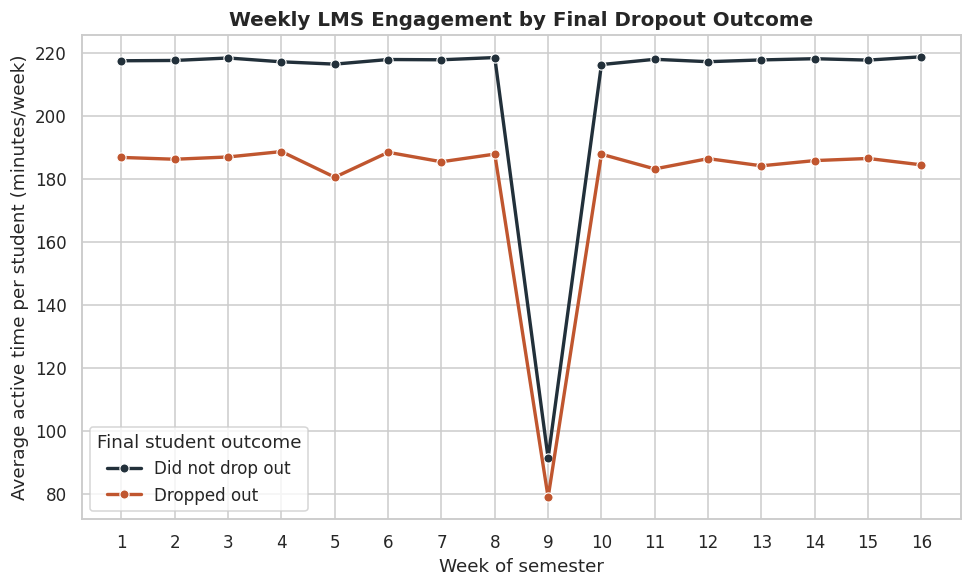

In [8]:
# Keep one outcome record per student before joining one-to-many weekly observations.
student_outcomes = students[["student_id", "dropped_out"]].drop_duplicates("student_id")
activity_outcomes = weekly.merge(student_outcomes, on="student_id", how="inner", validate="many_to_one")
activity_outcomes["Outcome"] = activity_outcomes["dropped_out"].map({0: "Did not drop out", 1: "Dropped out"})

outcome_weekly = (activity_outcomes
                  .groupby(["week", "Outcome"], as_index=False)["minutes_active"]
                  .mean())

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.lineplot(data=outcome_weekly, x="week", y="minutes_active", hue="Outcome",
             palette={"Did not drop out": NAVY, "Dropped out": RUST},
             marker="o", linewidth=2.2, ax=ax)
ax.set_title("Weekly LMS Engagement by Final Dropout Outcome")
ax.set_xlabel("Week of semester")
ax.set_ylabel("Average active time per student (minutes/week)")
ax.set_xticks(range(1, 17))
ax.legend(title="Final student outcome")
plt.tight_layout()
plt.show()

**STAR story**

- **Scope:** I asked whether the students who ultimately dropped out were already less engaged in the LMS early enough for Northgate to notice and respond.
- **Track:** I linked each student's final dropout outcome to weekly activity, then used two lines to compare average active minutes over time. The student file was deduplicated by ID before the merge to avoid overweighting 27 duplicated IDs.
- **Articulate:** The students who eventually dropped out were less active from the beginning. In Week 1 they averaged about **187 minutes**, compared with **218 minutes** for students who did not drop out—a gap of roughly **30 minutes per week**. A similar gap persists throughout the semester. Both groups experience the sharp Week 9 drop, suggesting that event affected the whole student body rather than only the eventual dropout group.
- **Respond:** Northgate could flag sustained low engagement during the first few weeks for supportive outreach, then combine it with GPA, workload, commute, and advising information rather than treating one measure as a verdict. Dropout status is an eventual outcome, so this retrospective association should be tested prospectively before it is used as an intervention rule.

## Overall takeaway

The clearest early signal is not a dramatic difference among majors; it is the persistent engagement gap for students who eventually drop out. At the same time, the negative work-hours value, duplicate IDs, inconsistent major labels, exact-zero GPAs, and Week 9 activity collapse show why Northgate should validate the data before automating decisions about students.